# Import

In [6]:
!pip install surprise


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [51]:
import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_squared_error


from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import cross_validate, train_test_split
from surprise import accuracy
from sklearn.metrics import roc_auc_score, confusion_matrix, precision_score, recall_score, ndcg_score, average_precision_score, ConfusionMatrixDisplay
import pandas as pd
import numpy as np

from surprise.model_selection import KFold

from collections import defaultdict

# EDA 

## User Data

In [8]:
users = pd.read_csv('/Users/gracefujinaga/MSDS_490/Data/u.data',  sep='\t', header=None)
columns_renamed = ['user_id', 'item_id', 'rating', 'timestamp']
users.columns = columns_renamed
users

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596
...,...,...,...,...
99995,880,476,3,880175444
99996,716,204,5,879795543
99997,276,1090,1,874795795
99998,13,225,2,882399156


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


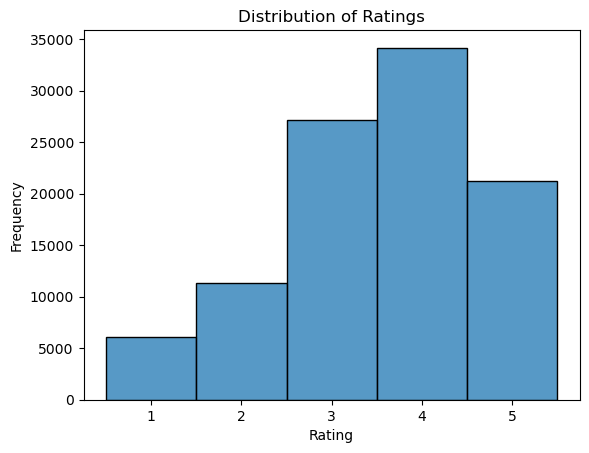

In [9]:
#plot histogram
sns.histplot(users['rating'], bins=range(6), edgecolor='black', discrete=True)

# set x axis labels
plt.xticks([ 1, 2, 3, 4, 5])

# label and title
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

#### Ratings Per User

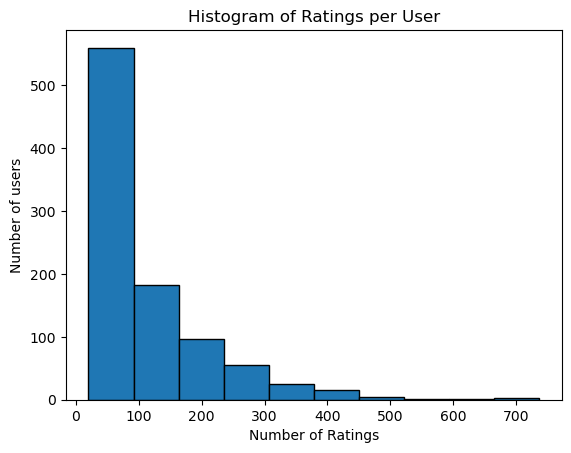

In [10]:
# plot of ratings
user_rating_counts = users.groupby('user_id').size().reset_index(name='count')

plt.hist(user_rating_counts['count'], edgecolor='black')

plt.title("Histogram of Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of users")

plt.show()


## Item Data

In [11]:
items = pd.read_csv('/Users/gracefujinaga/MSDS_490/Data/u.item', delimiter='|', dtype=None,encoding='latin-1', header=None)
columns_renamed = [
    "movie_id", "movie_title", "release_date", "video_release_date", "IMDb_URL",
    "unknown", "action", "adventure", "animation", "childrens", "comedy", "crime",
    "documentary", "drama", "fantasy", "film_noir", "horror", "musical", "mystery",
    "romance", "sci_fi", "thriller", "war", "western"
]
items.columns = columns_renamed
items

,movie_id,movie_title,release_date,video_release_date,IMDb_URL,unknown,action,adventure,animation,childrens,...,fantasy,film_noir,horror,musical,mystery,romance,sci_fi,thriller,war,western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,1678,Mat' i syn (1997),06-Feb-1998,NaN,http://us.imdb.com/M/title-exact?Mat%27+i+syn+...,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1678,1679,B. Monkey (1998),06-Feb-1998,NaN,http://us.imdb.com/M/title-exact?B%2E+Monkey+(...,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
1679,1680,Sliding Doors (1998),01-Jan-1998,NaN,http://us.imdb.com/Title?Sliding+Doors+(1998),0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1680,1681,You So Crazy (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?You%20So%20Cr...,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
# cleaning
items.drop(columns=['video_release_date'], inplace=True)

In [13]:
items

,movie_id,movie_title,release_date,IMDb_URL,unknown,action,adventure,animation,childrens,comedy,...,fantasy,film_noir,horror,musical,mystery,romance,sci_fi,thriller,war,western
0,1,Toy Story (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,1678,Mat' i syn (1997),06-Feb-1998,http://us.imdb.com/M/title-exact?Mat%27+i+syn+...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1678,1679,B. Monkey (1998),06-Feb-1998,http://us.imdb.com/M/title-exact?B%2E+Monkey+(...,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
1679,1680,Sliding Doors (1998),01-Jan-1998,http://us.imdb.com/Title?Sliding+Doors+(1998),0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1680,1681,You So Crazy (1994),01-Jan-1994,http://us.imdb.com/M/title-exact?You%20So%20Cr...,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


#### Handling NAN values

In [14]:
items.isna().sum()

movie_id        0
movie_title     0
release_date    1
IMDb_URL        3
unknown         0
action          0
adventure       0
animation       0
childrens       0
comedy          0
crime           0
documentary     0
drama           0
fantasy         0
film_noir       0
horror          0
musical         0
mystery         0
romance         0
sci_fi          0
thriller        0
war             0
western         0
dtype: int64

In [15]:
# 1 nan value in release_date and 3 in Imdb_url
nan_rows = items[items.isna().any(axis=1)]
nan_rows

,movie_id,movie_title,release_date,IMDb_URL,unknown,action,adventure,animation,childrens,comedy,...,fantasy,film_noir,horror,musical,mystery,romance,sci_fi,thriller,war,western
266,267,unknown,NaN,NaN,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1357,1358,The Deadly Cure (1996),16-Sep-1996,NaN,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1358,1359,Boys in Venice (1996),24-Sep-1996,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [16]:
print(type(items['IMDb_URL'][0]))
print(type(items['release_date'][0]))

<class 'str'>
<class 'str'>


In [17]:
items.iloc[266] 

movie_id            267
movie_title     unknown
release_date        NaN
IMDb_URL            NaN
unknown               1
action                0
adventure             0
animation             0
childrens             0
comedy                0
crime                 0
documentary           0
drama                 0
fantasy               0
film_noir             0
horror                0
musical               0
mystery               0
romance               0
sci_fi                0
thriller              0
war                   0
western               0
Name: 266, dtype: object

In [18]:
# just drop the unkown movie, no date, no genres --> doing nothing 
items = items[items['movie_id'] != 267]

In [19]:
# 1357, 1358 movie ids --> no imdb url
items.loc[items['movie_id'] == 1358,'IMDb_URL'] = 'no_url'
items.loc[items['movie_id'] == 1358]['IMDb_URL']

1357    no_url
Name: IMDb_URL, dtype: object

In [20]:
items.loc[items['movie_id'] == 1359,'IMDb_URL'] = 'no_url'
items.loc[items['movie_id'] == 1358]['IMDb_URL']

1357    no_url
Name: IMDb_URL, dtype: object

#### Graphs

In [99]:
items['release_date'] = pd.to_datetime(items['release_date'], format='%d-%b-%Y')

# convert to year
items.loc[:,'release_year'] = items['release_date'].dt.year

# get decade
items.loc[:,'decade'] = (items['release_year'] // 10) * 10

# group by year
movies_by_decade = items.groupby('decade')['movie_id'].count().reset_index()
movies_by_decade.columns = ['decade', 'count']
movies_by_decade

/var/folders/zv/4f9cw9vs6tjbvz5bh2k07w_40000gn/T/ipykernel_57643/4168290010.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  items['release_date'] = pd.to_datetime(items['release_date'], format='%d-%b-%Y')


,decade,count
0,1920,2
1,1930,29
2,1940,45
3,1950,54
4,1960,43
5,1970,53
6,1980,107
7,1990,1348


In [113]:
filtered_df = items[items['decade'] == 1990]

,movie_id,movie_title,release_date,IMDb_URL,unknown,action,adventure,animation,childrens,comedy,...,horror,musical,mystery,romance,sci_fi,thriller,war,western,release_year,decade
0,1,Toy Story (1995),1995-01-01,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,1995,1990
1,2,GoldenEye (1995),1995-01-01,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,0,...,0,0,0,0,0,1,0,0,1995,1990
2,3,Four Rooms (1995),1995-01-01,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1995,1990
3,4,Get Shorty (1995),1995-01-01,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1995,1990
4,5,Copycat (1995),1995-01-01,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1995,1990
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,1678,Mat' i syn (1997),1998-02-06,http://us.imdb.com/M/title-exact?Mat%27+i+syn+...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1998,1990
1678,1679,B. Monkey (1998),1998-02-06,http://us.imdb.com/M/title-exact?B%2E+Monkey+(...,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,1998,1990
1679,1680,Sliding Doors (1998),1998-01-01,http://us.imdb.com/Title?Sliding+Doors+(1998),0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1998,1990
1680,1681,You So Crazy (1994),1994-01-01,http://us.imdb.com/M/title-exact?You%20So%20Cr...,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1994,1990


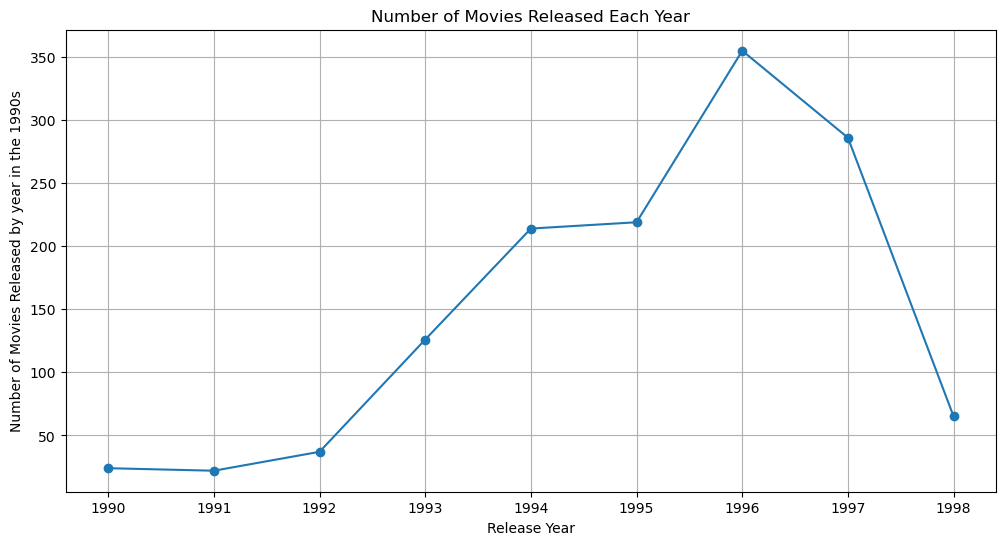

In [121]:
filtered_df = items[items['decade'] == 1990]
movies_per_year = filtered_df.groupby('release_year')['movie_id'].count().reset_index()


plt.figure(figsize=(12,6))
plt.plot(movies_per_year['release_year'], movies_per_year['movie_id'], marker='o')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies Released by year in the 1990s')
plt.title('Number of Movies Released Each Year')
plt.grid(True)
plt.show()

In [126]:
users

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596
...,...,...,...,...
99995,880,476,3,880175444
99996,716,204,5,879795543
99997,276,1090,1,874795795
99998,13,225,2,882399156


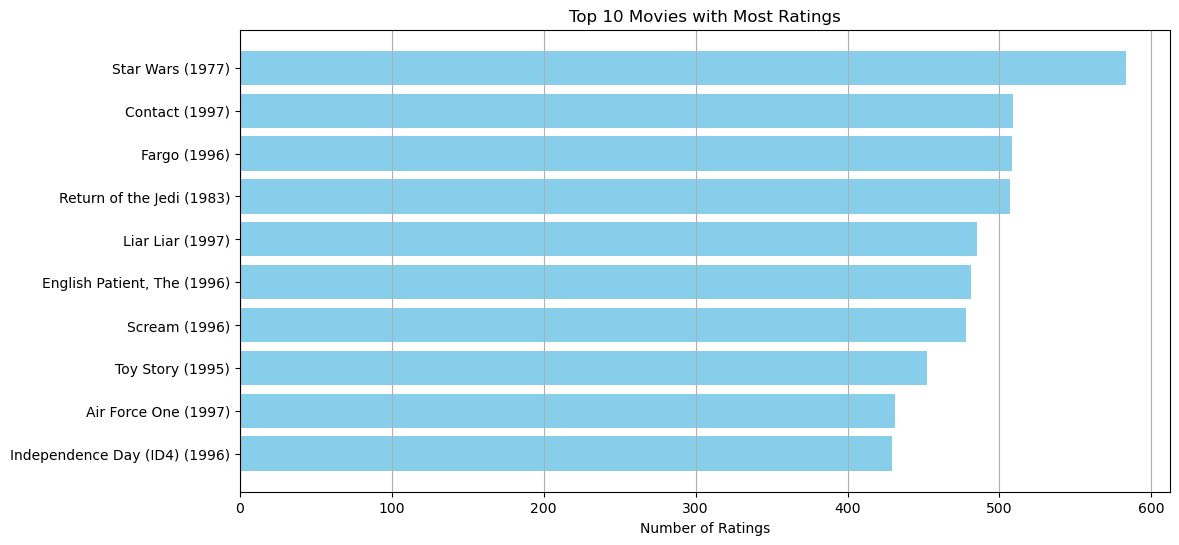

In [143]:
ratings_per_movie = users.groupby('item_id').count().reset_index()
ratings_per_movie['count'] = ratings_per_movie['user_id']

ratings_per_movie.drop(columns=['rating', 'timestamp'], inplace=True)
ratings_with_titles = ratings_per_movie.merge(items[['movie_id', 'movie_title']], left_on='item_id', right_on='movie_id')

# sort by num ratings
top_movies = ratings_with_titles.sort_values('count', ascending=False).head(10)

# plot
plt.figure(figsize=(12,6))
plt.barh(top_movies['movie_title'], top_movies['count'], color='skyblue')
plt.xlabel('Number of Ratings')
plt.title('Top 10 Movies with Most Ratings')
plt.gca().invert_yaxis() 
plt.grid(axis='x')
plt.show()

# Recommender Model

In [ ]:
# ## NORMALIZATION STEP ##

# skip for surprise

# # compute the row means
# row_means = np.true_divide(matrix.sum(1), (matrix != 0).sum(1))

# # Step 2: Subtract row mean only where rating is non-zero
# norm_matrix = matrix.copy().astype(float)
# for i in range(len(norm_matrix)):
#     for j in range(len(norm_matrix[0])):
#         if norm_matrix[i, j] != 0:
#             norm_matrix[i, j] -= row_means[i]

# Model and Metrics

In [31]:

# A reader is still needed but only the rating_scale param is required.
reader = Reader(rating_scale=(1, 5))

# The columns must correspond to user id, item id and ratings (in that order).
data = Dataset.load_from_df(users[['user_id', 'item_id', 'rating']], reader)

In [55]:
# helper functions for precision and recall
def precision_at_k(predictions, k=10, threshold=2.5):

    # map the predicitons to each user
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = dict()
    for uid, user_ratings in user_est_true.items():

        # Sort user ratings by estimated value
        user_ratings.sort(key=lambda x: x[0], reverse=True)

        # Number of recommended items in top k
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])

        # Number of relevant and recommended items in top k
        n_rel_and_rec_k = sum(
            ((true_r >= threshold) and (est >= threshold))
            for (est, true_r) in user_ratings[:k]
        )

        # Precision@K: Proportion of recommended items that are relevant
        # When n_rec_k is 0, Precision is undefined. We here set it to 0.
        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0

    return precisions

def recall_at_k(predictions, k=10, threshold=2.5):
     # First map the predictions to each user.
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    recalls = dict()
    for uid, user_ratings in user_est_true.items():

        # Sort user ratings by estimated value
        user_ratings.sort(key=lambda x: x[0], reverse=True)

        # Number of relevant items
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)

        # Number of recommended items in top k
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])

        # Number of relevant and recommended items in top k
        n_rel_and_rec_k = sum(
            ((true_r >= threshold) and (est >= threshold))
            for (est, true_r) in user_ratings[:k]
        )

        # Recall@K: Proportion of relevant items that are recommended
        # When n_rel is 0, Recall is undefined. We here set it to 0.
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    return recalls


In [59]:
# define a cross-validation iterator
kf = KFold(n_splits=5)

algo = SVD()

# set up metrics
all_precisions = []
all_recalls = []
all_ndcg = []
all_map = []
all_auc = []
y_true_all = []
y_pred_all = []
all_rmse = []


for trainset, testset in kf.split(data):

    # train and test algorithm.
    algo.fit(trainset)
    predictions = algo.test(testset)

    # rmse
    rmse = accuracy.rmse(predictions)
    all_rmse.append(rmse)

    # get true and predicted labels
    y_true = [pred.r_ui for pred in predictions]
    y_pred = [pred.est for pred in predictions]

    # confusion matrix
    threshold = 2.5
    y_true_binary = [1 if true >= threshold else 0 for true in y_true]
    y_pred_binary = [1 if pred >= threshold else 0 for pred in y_pred]
    y_true_all.extend(y_true_binary)
    y_pred_all.extend(y_pred_binary)

    # AUC
    auc = roc_auc_score(y_true_binary, y_pred_binary)
    all_auc.append(auc)

    # precision@10, recall@10
    precisions = precision_at_k(predictions, k=10, threshold=2.5)
    recalls = recall_at_k(predictions, k=10, threshold =2.5)
    all_precisions.append(sum(prec for prec in precisions.values()) / len(precisions))
    all_recalls.append(sum(rec for rec in recalls.values()) / len(recalls))
    
    # nDCG
    # reshape to 2d array
    ncdg = ndcg_score([y_true], [y_pred])  
    all_ndcg.append(ncdg)

    # MAP
    map = average_precision_score(y_true_binary, y_pred_binary)
    all_map.append(map)

# RMSE
print(f"mean rmse: {np.mean(all_rmse)}")

# Precision@K
print(f"mean precision@k: {np.mean(all_precisions)}")

# Recall@K
print(f"mean recall@k: {np.mean(all_recalls)}")

# nDCG
print(f"mean nCDG: {np.mean(all_ndcg)}")

# MAP
print(f"mean average precision: {np.mean(all_map)}")

# AUC
print(f"mean auc: {np.mean(all_auc)}")


RMSE: 0.9302
RMSE: 0.9385
RMSE: 0.9292
RMSE: 0.9454
RMSE: 0.9355
mean rmse: 0.9357475333267967
mean precision@k: 0.8907393179432329
mean recall@k: 0.6794742484221015
mean nCDG: 0.9878267465300643
mean average precision: 0.8561543163154004
mean auc: 0.6033286230819821


# Confusion Matrix

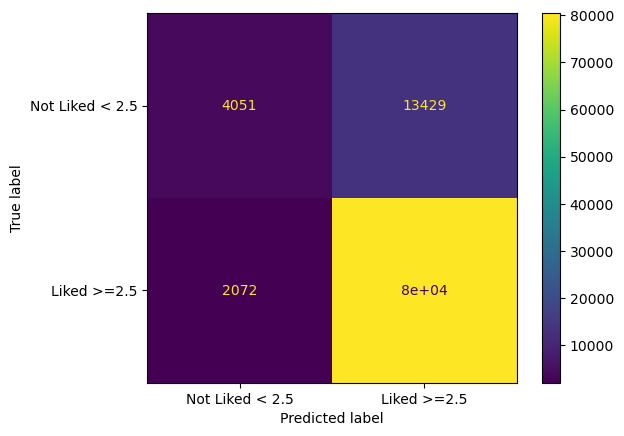

mean rmse: 0.9357475333267967
mean precision@k: 0.8907393179432329
mean recall@k: 0.6794742484221015
mean nCDG: 0.9878267465300643
mean average precision: 0.8561543163154004
mean auc: 0.6033286230819821


In [60]:
confusion_matrix(y_true_all, y_pred_all)

cm = confusion_matrix(y_true_all, y_pred_all,)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Liked < 2.5", "Liked >=2.5"])
disp.plot()
plt.show()

# RMSE
print(f"mean rmse: {np.mean(all_rmse)}")

# Precision@K
print(f"mean precision@k: {np.mean(all_precisions)}")

# Recall@K
print(f"mean recall@k: {np.mean(all_recalls)}")

# nDCG
print(f"mean nCDG: {np.mean(all_ndcg)}")

# MAP
print(f"mean average precision: {np.mean(all_map)}")

# AUC
print(f"mean auc: {np.mean(all_auc)}")


# Predict and show top ten movie recommendations

In [ ]:
user_id = 12

# get all item ids
trainset = algo.trainset
all_item_raw_ids = [trainset.to_raw_iid(inner_id) for inner_id in trainset.all_items()]

# get what is rated
user_inner_id = trainset.to_inner_uid(user_id)
user_rated_raw_items = set(trainset.to_raw_iid(inner_id) for inner_id, _ in trainset.ur[user_inner_id])

# get what hasnt been rated
items_to_predict = [item for item in all_item_raw_ids if item not in user_rated_raw_items]


In [90]:
#### SELECT USER####
user_id = 12 # needs to be int 
#######  

# Get all items the user has NOT rated yet
trainset = algo.trainset

# Get all item ids
all_items = trainset.all_items()
all_item_raw_ids = [num for num in all_items]

# get itmems the user hasnt rated yet
user_rated_items = set([trainset.to_raw_iid(j) for (j, _) in trainset.ur[trainset.to_inner_uid(user_id)]])
items_to_predict = [item for item in all_item_raw_ids if item not in user_rated_items]

# Predict ratings for all unseen items
predictions = []
for item_id in items_to_predict:
    pred = algo.predict(user_id, item_id)
    predictions.append((item_id, pred.est))

# sort by rating
predictions.sort(key=lambda x: x[1], reverse=True)

# Get top 10 recommendations
top_10_items = predictions[:10]
top_10_df = pd.DataFrame(top_10_items, columns=['movie_id', 'predicted_rating'])

# now merge with the movies info
top_ten_rec = items[items["movie_id"].isin(top_10_df['movie_id'])]
top_ten_rec = top_ten_rec[['movie_id', 'movie_title']]
top_ten_rec = top_ten_rec.merge(top_10_df, on='movie_id', how='inner')
top_ten_rec = top_ten_rec.sort_values(by='predicted_rating', ascending=False).reset_index(drop=True)

print(f"recommendations for user: {user_id}")
top_ten_rec

recommendations for user: 12


,movie_id,movie_title,predicted_rating
0,272,Good Will Hunting (1997),5.000000
1,64,"Shawshank Redemption, The (1994)",4.949674
2,313,Titanic (1997),4.944434
3,963,Some Folks Call It a Sling Blade (1993),4.919883
4,178,12 Angry Men (1957),4.904843
5,251,Shall We Dance? (1996),4.900281
6,210,Indiana Jones and the Last Crusade (1989),4.877472
7,79,"Fugitive, The (1993)",4.869314
8,657,"Manchurian Candidate, The (1962)",4.844957
9,408,"Close Shave, A (1995)",4.824275
